# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ashoktanakanti/flyrank_ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The queue: what to do first, and why, in words a human trusts. I blend the model's
probability (70%) with the baseline rule score (30%) into one final score, then map each
page to one action based on its reason codes.

**Actions:** `refresh` (general priority review), `refresh_and_review_ctr` (good position,
weak CTR — likely a title/meta problem), `monitor_closely` (elevated risk, not urgent yet),
`monitor` (no strong signal).

In [ ]:
import os
import pandas as pd
import numpy as np
from datasets import load_dataset
from huggingface_hub import login, notebook_login
from sklearn.ensemble import RandomForestClassifier

HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
else:
    notebook_login()
    HF_TOKEN = os.environ.get("HF_TOKEN")

data_files = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"
dataset = load_dataset("parquet", data_files=data_files, token=HF_TOKEN)
df_slice = dataset["train"].to_pandas()
df_slice["report_date"] = pd.to_datetime(df_slice["report_date"])

page = df_slice.groupby("content_hash_id").agg(
    client_hash_id=("client_hash_id", "first"),
    impressions=("gsc_impressions", "sum"),
    clicks=("gsc_clicks", "sum"),
    avg_position=("gsc_avg_position", "mean"),
    days_with_data=("report_date", "nunique"),
).reset_index()
page["ctr"] = np.where(page["impressions"] > 0, page["clicks"] / page["impressions"], 0)

median_date = df_slice["report_date"].median()
first_clicks = df_slice[df_slice["report_date"] < median_date].groupby("content_hash_id")["gsc_clicks"].sum()
second_clicks = df_slice[df_slice["report_date"] >= median_date].groupby("content_hash_id")["gsc_clicks"].sum()
page["first_half_clicks"] = page["content_hash_id"].map(first_clicks).fillna(0)
page["second_half_clicks"] = page["content_hash_id"].map(second_clicks).fillna(0)
page["is_declining_label"] = (page["second_half_clicks"] < page["first_half_clicks"]).astype(int)

RANDOM_STATE = 42
feature_cols = ["impressions", "clicks", "avg_position", "ctr", "days_with_data"]
X = page[feature_cols].fillna(0)
y = page["is_declining_label"]

model = RandomForestClassifier(class_weight="balanced_subsample", max_depth=10,
                                min_samples_leaf=25, n_estimators=200,
                                random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X, y)
page["model_probability"] = model.predict_proba(X)[:, 1]

# Baseline score (same formula as ML-07)
demand = page["impressions"].rank(pct=True)
low_consistency = 1 - page["days_with_data"].rank(pct=True)
has_position = page["avg_position"] > 0
position_opportunity = pd.Series(0.0, index=page.index)
position_opportunity[has_position] = (1 - page.loc[has_position, "avg_position"].clip(upper=50) / 50).rank(pct=True)
page["baseline_score_0_1"] = (0.45 * demand + 0.35 * low_consistency + 0.20 * position_opportunity)

page["final_score"] = (0.7 * page["model_probability"] + 0.3 * page["baseline_score_0_1"]) * 100

def reason_codes(row):
    reasons = []
    if row["model_probability"] >= 0.65:
        reasons.append("model_decline_risk")
    if row["is_declining_label"] == 1 and row["impressions"] >= 100:
        reasons.append("declining_with_demand")
    if row["avg_position"] > 0 and row["avg_position"] <= 20 and row["ctr"] < 0.02 and row["impressions"] >= 500:
        reasons.append("low_ctr_visible_page")
    if row["days_with_data"] <= page["days_with_data"].median() and row["impressions"] >= 500:
        reasons.append("low_consistency_visible_page")
    return "|".join(reasons) if reasons else "general_refresh_review"

page["reason_codes"] = page.apply(reason_codes, axis=1)

def suggested_action(row):
    reasons = set(row["reason_codes"].split("|"))
    if "low_ctr_visible_page" in reasons and ("model_decline_risk" in reasons or "declining_with_demand" in reasons):
        return "refresh_and_review_ctr"
    if "model_decline_risk" in reasons or "declining_with_demand" in reasons:
        return "refresh"
    if row["final_score"] >= page["final_score"].median():
        return "monitor_closely"
    return "monitor"

page["suggested_action"] = page.apply(suggested_action, axis=1)

ranked_queue = page.sort_values("final_score", ascending=False).reset_index(drop=True)
ranked_queue["rank"] = ranked_queue.index + 1

print("Top 15 ranked actions:")
display(ranked_queue[["rank", "content_hash_id", "final_score", "suggested_action",
                       "reason_codes", "impressions", "avg_position", "ctr"]].head(15))

print("\nAction mix:")
print(ranked_queue["suggested_action"].value_counts())

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Top 15 ranked actions:


,rank,content_hash_id,final_score,suggested_action,reason_codes,impressions,avg_position,ctr
0,1,content_c23e38ebddabf6e8,87.532124,refresh_and_review_ctr,model_decline_risk|declining_with_demand|low_c...,2936,1.803852,0.000341
1,2,content_133ae7f99489ec89,87.521075,refresh_and_review_ctr,model_decline_risk|declining_with_demand|low_c...,4167,1.659045,0.000240
2,3,content_de170fa8c86c7e24,87.498672,refresh_and_review_ctr,model_decline_risk|declining_with_demand|low_c...,2905,2.169814,0.000344
3,4,content_210ff8ad8fe0c0b6,87.494237,refresh_and_review_ctr,model_decline_risk|declining_with_demand|low_c...,2872,2.340131,0.000348
4,5,content_fade25391a8f6928,87.487188,refresh_and_review_ctr,model_decline_risk|declining_with_demand|low_c...,3169,1.838433,0.000316
5,6,content_91e24512e75555e1,87.482150,refresh_and_review_ctr,model_decline_risk|declining_with_demand|low_c...,3141,2.197568,0.000318
6,7,content_269c3ff4fcd5a7f0,87.476796,refresh_and_review_ctr,model_decline_risk|declining_with_demand|low_c...,4029,2.902423,0.000248
7,8,content_002109dbd8a04596,87.476540,refresh_and_review_ctr,model_decline_risk|declining_with_demand|low_c...,2932,3.124699,0.000341
8,9,content_4ce40288542e4b76,87.468909,refresh_and_review_ctr,model_decline_risk|declining_with_demand|low_c...,3278,3.197704,0.000305
9,10,content_7c954bc46e5452c3,87.458444,refresh_and_review_ctr,model_decline_risk|declining_with_demand|low_c...,3130,3.226400,0.000319



Action mix:
suggested_action
monitor                   162924
monitor_closely           104397
refresh_and_review_ctr     40523
refresh                    23593
Name: count, dtype: int64


## 2. Intended use and limits

**Who uses this:** a content strategist or SEO editor deciding where to spend limited weekly
review time — not an automated publishing system.

**What it's for:** surfacing candidates worth a human look, with a reason attached, so the
editor isn't starting from zero every week.

**Where it stops being valid:**
- Beyond the March 2026 slice this was trained on — client behavior and seasonality shift,
  so this queue should be refreshed monthly, not treated as permanent.
- For any client not represented in training data (a brand-new client with no history yet).
- As a stand-alone justification for a specific editorial decision — it's a starting point,
  not evidence a change will work.
- For anything resembling a claim about *why* Google ranks a page a certain way — this model
  never touches ranking-algorithm internals, only observed search/engagement outcomes.

In [ ]:
print("Intended use: weekly reviewer aid for Lane 2 (Refresh / Content Opportunity Scoring).")
print("Validity window: this month's slice (2026-03) only — re-run monthly.")
print(f"Clients represented in this queue: {page['client_hash_id'].nunique()}")

Intended use: weekly reviewer aid for Lane 2 (Refresh / Content Opportunity Scoring).
Validity window: this month's slice (2026-03) only — re-run monthly.
Clients represented in this queue: 55


## 3. Human review + the no-go list

**What a person must check before acting:**
- Open the actual page and confirm the reason code still makes sense (e.g. a real CTR
  problem, not a seasonal dip).
- Check for any recent site-wide change (redesign, migration, algorithm update) that could
  explain the drop better than a content-quality issue.
- Confirm the page still matches current business priorities before investing edit time.

**What should NEVER be automated from this queue:**
- Auto-publishing any content change based on the score alone.
- Auto-pruning or de-indexing a page — that's a high-consequence, hard-to-reverse action and
  needs full manual sign-off every time.
- Treating `model_probability` as a guarantee for any single page — it's a ranking signal
  across many pages, not a certified diagnosis for one.

In [ ]:
no_go_actions = ["auto_publish", "auto_prune", "auto_deindex"]
print("No-go list (never automated from this queue):", no_go_actions)
print("\nHuman-review checklist before acting on any 'refresh' or 'refresh_and_review_ctr' row:")
print("1. Confirm reason code still holds by opening the page")
print("2. Check for site-wide events that could explain the pattern")
print("3. Confirm against current business priority before spending edit time")

No-go list (never automated from this queue): ['auto_publish', 'auto_prune', 'auto_deindex']

Human-review checklist before acting on any 'refresh' or 'refresh_and_review_ctr' row:
1. Confirm reason code still holds by opening the page
2. Check for site-wide events that could explain the pattern
3. Confirm against current business priority before spending edit time


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

- **Base rate drift:** if the overall declining rate moves meaningfully away from this
  month's observed rate, the model's calibration should be rechecked.
- **New client onboarding:** any client with no prior month in the training window should be
  treated with lower confidence until at least one full month of data exists for them.
- **Precision@50 drop:** if a future month's holdout precision@50 falls notably below this
  month's number, retrain rather than keep using the current model.
- **Scheduled retrain:** monthly, using the newest mid-panel month, following the same
  client-holdout validation design as ML-08/ML-09.

In [ ]:
current_base_rate = page["is_declining_label"].mean()
print(f"Current base rate (declining share, 2026-03): {current_base_rate:.1%}")
print("Retrain trigger thresholds to monitor going forward:")
print(f"  - Base rate drifts beyond roughly {current_base_rate - 0.10:.0%}-{current_base_rate + 0.10:.0%}")
print("  - Any client with zero prior months of history -> flag as low-confidence")
print("  - Next month's client-holdout Precision@50 falls notably below this month's number")

Current base rate (declining share, 2026-03): 8.7%
Retrain trigger thresholds to monitor going forward:
  - Base rate drifts beyond roughly -1%-19%
  - Any client with zero prior months of history -> flag as low-confidence
  - Next month's client-holdout Precision@50 falls notably below this month's number


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on
these files.*

Wrote 331,437 rows to work/outputs/action_playbook_queue.csv


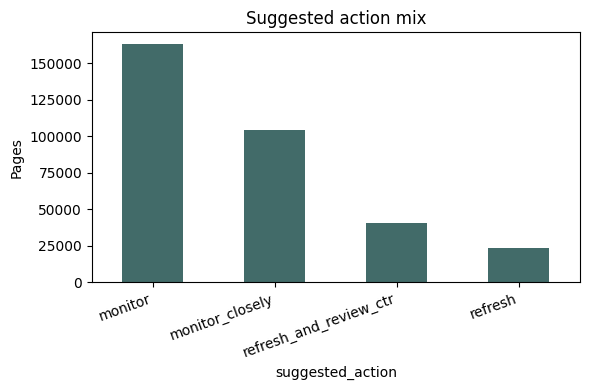

Wrote work/figures/action_playbook_mix.png

Summary for the paper:
Total pages scored: 331,437
High-priority (refresh actions): 64,116


In [ ]:
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

export_cols = ["rank", "content_hash_id", "client_hash_id", "final_score", "model_probability",
               "baseline_score_0_1", "suggested_action", "reason_codes",
               "impressions", "avg_position", "ctr", "days_with_data", "is_declining_label"]
ranked_queue[export_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(ranked_queue):,} rows to work/outputs/action_playbook_queue.csv")

# Figure: action mix chart, reusable in the paper
fig, ax = plt.subplots(figsize=(6, 4))
ranked_queue["suggested_action"].value_counts().plot(kind="bar", ax=ax, color="#426B69")
ax.set_title("Suggested action mix")
ax.set_ylabel("Pages")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("work/figures/action_playbook_mix.png", dpi=150)
plt.show()

print("Wrote work/figures/action_playbook_mix.png")
print("\nSummary for the paper:")
print(f"Total pages scored: {len(ranked_queue):,}")
print(f"High-priority (refresh actions): {(ranked_queue['suggested_action'].isin(['refresh', 'refresh_and_review_ctr'])).sum():,}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.